In [4]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score,root_mean_squared_error,mean_absolute_error


In [5]:
conn=sqlite3.connect('/Users/shrey/Great_learning/frieght_cost_classficaion_project/Inventory-Invoice-Analytics/data/inventory.db')
tables=pd.read_sql_query("select name from sqlite_master where type='table'",conn)
tables

,name
0,purchases
1,purchase_prices
2,vendor_invoice
3,begin_inventory
4,end_inventory


In [6]:
for name in tables['name']:
    print('Table: ',name)
    display(pd.read_sql(f"select * from {name} limit 5",conn))

Table:  purchases


,InventoryId,Store,Brand,Description,Size,VendorNumber,VendorName,PONumber,PODate,ReceivingDate,InvoiceDate,PayDate,PurchasePrice,Quantity,Dollars,Classification
0,69_MOUNTMEND_8412,69,8412,Tequila Ocho Plata Fresno,750mL,105,ALTAMAR BRANDS LLC,8124,2023-12-21,2024-01-02,2024-01-04,2024-02-16,35.71,6,214.26,1
1,30_CULCHETH_5255,30,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,4,37.40,1
2,34_PITMERDEN_5215,34,5215,TGI Fridays Long Island Iced,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-02,2024-01-07,2024-02-21,9.41,5,47.05,1
3,1_HARDERSFIELD_5255,1,5255,TGI Fridays Ultimte Mudslide,1.75L,4466,AMERICAN VINTAGE BEVERAGE,8137,2023-12-22,2024-01-01,2024-01-07,2024-02-21,9.35,6,56.10,1
4,76_DONCASTER_2034,76,2034,Glendalough Double Barrel,750mL,388,ATLANTIC IMPORTING COMPANY,8169,2023-12-24,2024-01-02,2024-01-09,2024-02-16,21.32,5,106.60,1


Table:  purchase_prices


,Brand,Description,Price,Size,Volume,Classification,PurchasePrice,VendorNumber,VendorName
0,58,Gekkeikan Black & Gold Sake,12.99,750mL,750,1,9.28,8320,SHAW ROSS INT L IMP LTD
1,62,Herradura Silver Tequila,36.99,750mL,750,1,28.67,1128,BROWN-FORMAN CORP
2,63,Herradura Reposado Tequila,38.99,750mL,750,1,30.46,1128,BROWN-FORMAN CORP
3,72,No. 3 London Dry Gin,34.99,750mL,750,1,26.11,9165,ULTRA BEVERAGE COMPANY LLP
4,75,Three Olives Tomato Vodka,14.99,750mL,750,1,10.94,7245,PROXIMO SPIRITS INC.


Table:  vendor_invoice


,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None


Table:  begin_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,startDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,8,12.99,2024-01-01
1,1_HARDERSFIELD_60,1,HARDERSFIELD,60,Canadian Club 1858 VAP,750mL,7,10.99,2024-01-01
2,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,6,36.99,2024-01-01
3,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,3,38.99,2024-01-01
4,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,6,34.99,2024-01-01


Table:  end_inventory


,InventoryId,Store,City,Brand,Description,Size,onHand,Price,endDate
0,1_HARDERSFIELD_58,1,HARDERSFIELD,58,Gekkeikan Black & Gold Sake,750mL,11,12.99,2024-12-31
1,1_HARDERSFIELD_62,1,HARDERSFIELD,62,Herradura Silver Tequila,750mL,7,36.99,2024-12-31
2,1_HARDERSFIELD_63,1,HARDERSFIELD,63,Herradura Reposado Tequila,750mL,7,38.99,2024-12-31
3,1_HARDERSFIELD_72,1,HARDERSFIELD,72,No. 3 London Dry Gin,750mL,4,34.99,2024-12-31
4,1_HARDERSFIELD_75,1,HARDERSFIELD,75,Three Olives Tomato Vodka,750mL,7,14.99,2024-12-31


In [7]:
vendor_df=pd.read_sql_query("Select * from vendor_invoice",conn)
vendor_df

,VendorNumber,VendorName,InvoiceDate,PONumber,PODate,PayDate,Quantity,Dollars,Freight,Approval
0,105,ALTAMAR BRANDS LLC,2024-01-04,8124,2023-12-21,2024-02-16,6,214.26,3.47,None
1,4466,AMERICAN VINTAGE BEVERAGE,2024-01-07,8137,2023-12-22,2024-02-21,15,140.55,8.57,None
2,388,ATLANTIC IMPORTING COMPANY,2024-01-09,8169,2023-12-24,2024-02-16,5,106.60,4.61,None
3,480,BACARDI USA INC,2024-01-12,8106,2023-12-20,2024-02-05,10100,137483.78,2935.20,None
4,516,BANFI PRODUCTS CORP,2024-01-07,8170,2023-12-24,2024-02-12,1935,15527.25,429.20,None
...,...,...,...,...,...,...,...,...,...,...
5538,9622,WEIN BAUER INC,2025-01-06,13626,2024-12-21,2025-02-10,90,1563.00,8.60,None
5539,9625,WESTERN SPIRITS BEVERAGE CO,2025-01-10,13661,2024-12-23,2025-02-18,4617,37300.48,186.50,None
5540,3664,WILLIAM GRANT & SONS INC,2025-01-02,13643,2024-12-22,2025-02-04,9848,202815.78,932.95,None
5541,9815,WINE GROUP INC,2025-01-03,13602,2024-12-20,2025-02-08,24747,149007.56,819.54,None


In [8]:
vendor_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5543 entries, 0 to 5542
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   VendorNumber  5543 non-null   int64  
 1   VendorName    5543 non-null   object 
 2   InvoiceDate   5543 non-null   object 
 3   PONumber      5543 non-null   int64  
 4   PODate        5543 non-null   object 
 5   PayDate       5543 non-null   object 
 6   Quantity      5543 non-null   int64  
 7   Dollars       5543 non-null   float64
 8   Freight       5543 non-null   float64
 9   Approval      374 non-null    object 
dtypes: float64(2), int64(3), object(5)
memory usage: 433.2+ KB


In [9]:
vendor_df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,5543.0,20662.752120,34582.158410,2.00,3089.00,7240.00,10754.000,201359.00
PONumber,5543.0,10889.419087,1600.859969,8106.00,9503.50,10890.00,12275.500,13661.00
Quantity,5543.0,6058.880931,14453.338164,1.00,83.00,423.00,5100.500,141660.00
Dollars,5543.0,58073.383642,140234.031377,4.14,967.81,4765.45,44587.175,1660435.88
Freight,5543.0,295.954301,713.585093,0.02,5.02,24.73,229.660,8468.22


In [10]:
vendor_df.isnull().sum()

VendorNumber       0
VendorName         0
InvoiceDate        0
PONumber           0
PODate             0
PayDate            0
Quantity           0
Dollars            0
Freight            0
Approval        5169
dtype: int64

In [11]:
vendor_df.duplicated().sum()

np.int64(0)

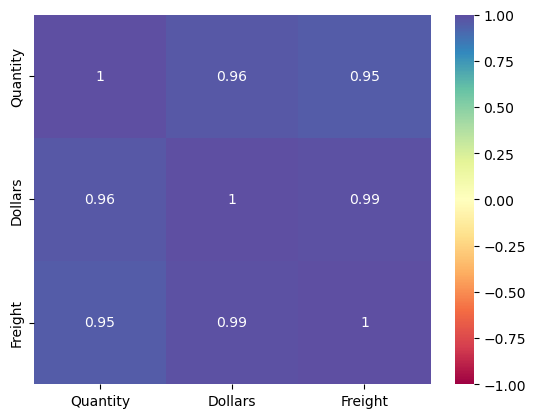

In [12]:
sns.heatmap(vendor_df[['Quantity','Dollars','Freight']].corr(numeric_only=True),annot=True,vmin=-1,vmax=1,cmap='Spectral')
plt.show()

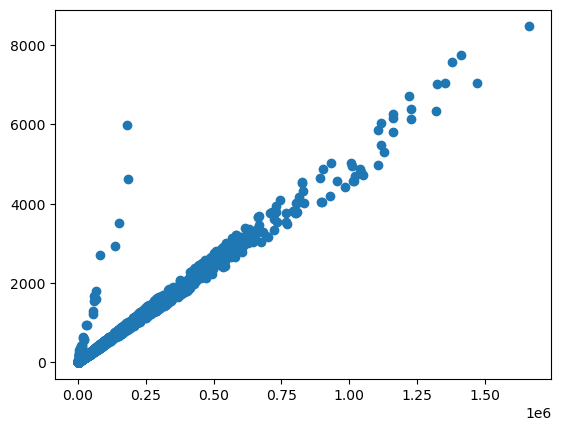

In [13]:
plt.scatter(vendor_df['Dollars'],vendor_df['Freight'])
plt.show()

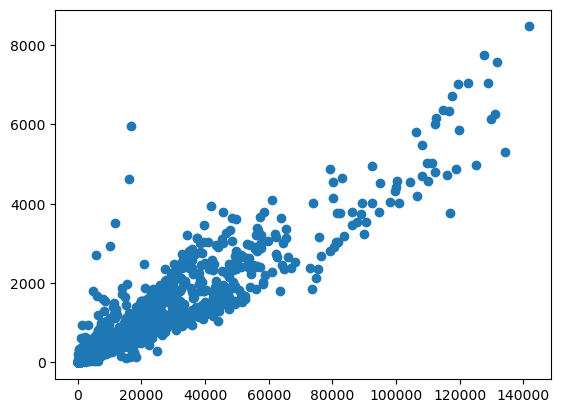

In [14]:
plt.scatter(vendor_df['Quantity'],vendor_df['Freight'])
plt.show()

In [15]:
# comparing the Avergae freight cost per unit for low quantity and high quantity order
vendor_df['freight_cost_per_unit']=vendor_df['Freight']/vendor_df['Quantity']
low_quantity_cap=vendor_df['Quantity'].quantile(0.25)
high_quantity_cap=vendor_df['Quantity'].quantile(0.75)



In [16]:
low_qty_fpu=vendor_df.loc[vendor_df['Quantity']<low_quantity_cap,'freight_cost_per_unit'].mean()
high_qty_fpu=vendor_df.loc[vendor_df['Quantity']>high_quantity_cap,'freight_cost_per_unit'].mean()
print(low_qty_fpu)
print(high_qty_fpu)

0.09489854253138316
0.049077654690759046


In [17]:
def get_performance_metrics(model,target,predictors):
    y_pred=model.predict(predictors)
    r2=r2_score(target,y_pred)
    mae=mean_absolute_error(target,y_pred)
    rmse=root_mean_squared_error(target,y_pred)
    print("R2 score",r2)
    print("Mean absolute error",mae)
    print("Root mean squared error",rmse)
    

In [31]:
X=vendor_df[['Dollars']]
y=vendor_df['Freight']
X

,Dollars
0,214.26
1,140.55
2,106.60
3,137483.78
4,15527.25
...,...
5538,1563.00
5539,37300.48
5540,202815.78
5541,149007.56


In [19]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [20]:
model1=LinearRegression()
model1.fit(X_train,y_train)

LinearRegression()

In [32]:
prediction_frieght=model1.predict(pd.DataFrame({'Dollars':74.65},index=[0]))
prediction_frieght

array([5.38240309])

In [21]:
model2=DecisionTreeRegressor()
model2.fit(X_train,y_train)

DecisionTreeRegressor()

In [22]:
model3=RandomForestRegressor()
model3.fit(X_train,y_train)

RandomForestRegressor()

In [23]:
print('Linear Regression Train results')
get_performance_metrics(model1,y_train,X_train)

Linear Regression Train results
R2 score 0.9706608671857476
Mean absolute error 24.945909782037866
Root mean squared error 121.99677794963497


In [24]:
print('Linear Regression Test results')
get_performance_metrics(model1,y_test,X_test)

Linear Regression Test results
R2 score 0.9698787714456558
Mean absolute error 24.105977072875714
Root mean squared error 124.72096203547433


In [25]:
print('Decision Regression Train results')
get_performance_metrics(model2,y_train,X_train)

Decision Regression Train results
R2 score 0.999999868444775
Mean absolute error 0.01707176865634241
Root mean squared error 0.25833233839250447


In [26]:
print('Decision Regression Test results')
get_performance_metrics(model2,y_test,X_test)

Decision Regression Test results
R2 score 0.9480852836268119
Mean absolute error 32.647608330828575
Root mean squared error 163.73757505794222


In [27]:
print('Random Forest Train results')
get_performance_metrics(model3,y_train,X_train)

Random Forest Train results
R2 score 0.992740102056075
Mean absolute error 11.546842760850774
Root mean squared error 60.686205299115066


In [28]:
print('Random Forest test results')
get_performance_metrics(model3,y_test,X_test)

Random Forest test results
R2 score 0.9595312689158801
Mean absolute error 28.50268074432457
Root mean squared error 144.56491491781279
